In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First look:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


=== Fraud Rate Analysis ===
Legitimate transactions: 284,315 (99.827%)
Fraudulent transactions: 492 (0.173%)

Imbalance ratio: 578:1
(For every 1 fraud there are 578 legitimate transactions)


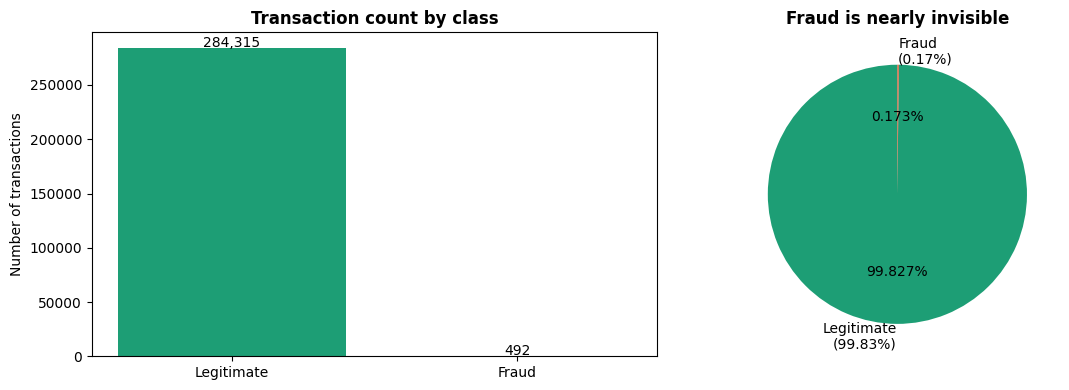

Chart saved


In [2]:
# ============================================================
# Understanding the fraud rate
# ============================================================

fraud_counts = df['Class'].value_counts()
fraud_pct    = df['Class'].value_counts(normalize=True) * 100

print("=== Fraud Rate Analysis ===")
print(f"Legitimate transactions: {fraud_counts[0]:,} ({fraud_pct[0]:.3f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]:,} ({fraud_pct[1]:.3f}%)")
print(f"\nImbalance ratio: {fraud_counts[0]/fraud_counts[1]:.0f}:1")
print(f"(For every 1 fraud there are {fraud_counts[0]/fraud_counts[1]:.0f} legitimate transactions)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], 
            fraud_counts.values,
            color=['#1D9E75', '#D85A30'])
axes[0].set_title('Transaction count by class', fontweight='bold')
axes[0].set_ylabel('Number of transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart to show how invisible fraud is
axes[1].pie(fraud_counts.values, 
            labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
            colors=['#1D9E75', '#D85A30'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Fraud is nearly invisible', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

# Fraud Detection Model — EDA & Data Understanding

## Dataset
Credit card transactions by European cardholders — September 2013
- 284,807 transactions over 2 days
- 492 fraudulent transactions (0.173%)
- Imbalance ratio: 578:1

## Key challenge
Extreme class imbalance makes accuracy a useless metric. Model must be evaluated on Precision, Recall, F1, and AUC-PR.

## Note on features
V1-V28 are PCA-transformed components of original transaction features — anonymised for confidentiality. Only Time and Amount are in their original form.

In [3]:
# ============================================================
# Data Quality Check
# ============================================================

print("=== Data Types & Missing Values ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     2848

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


C:\Users\amitb\AppData\Local\Temp\ipykernel_16584\3067385963.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([


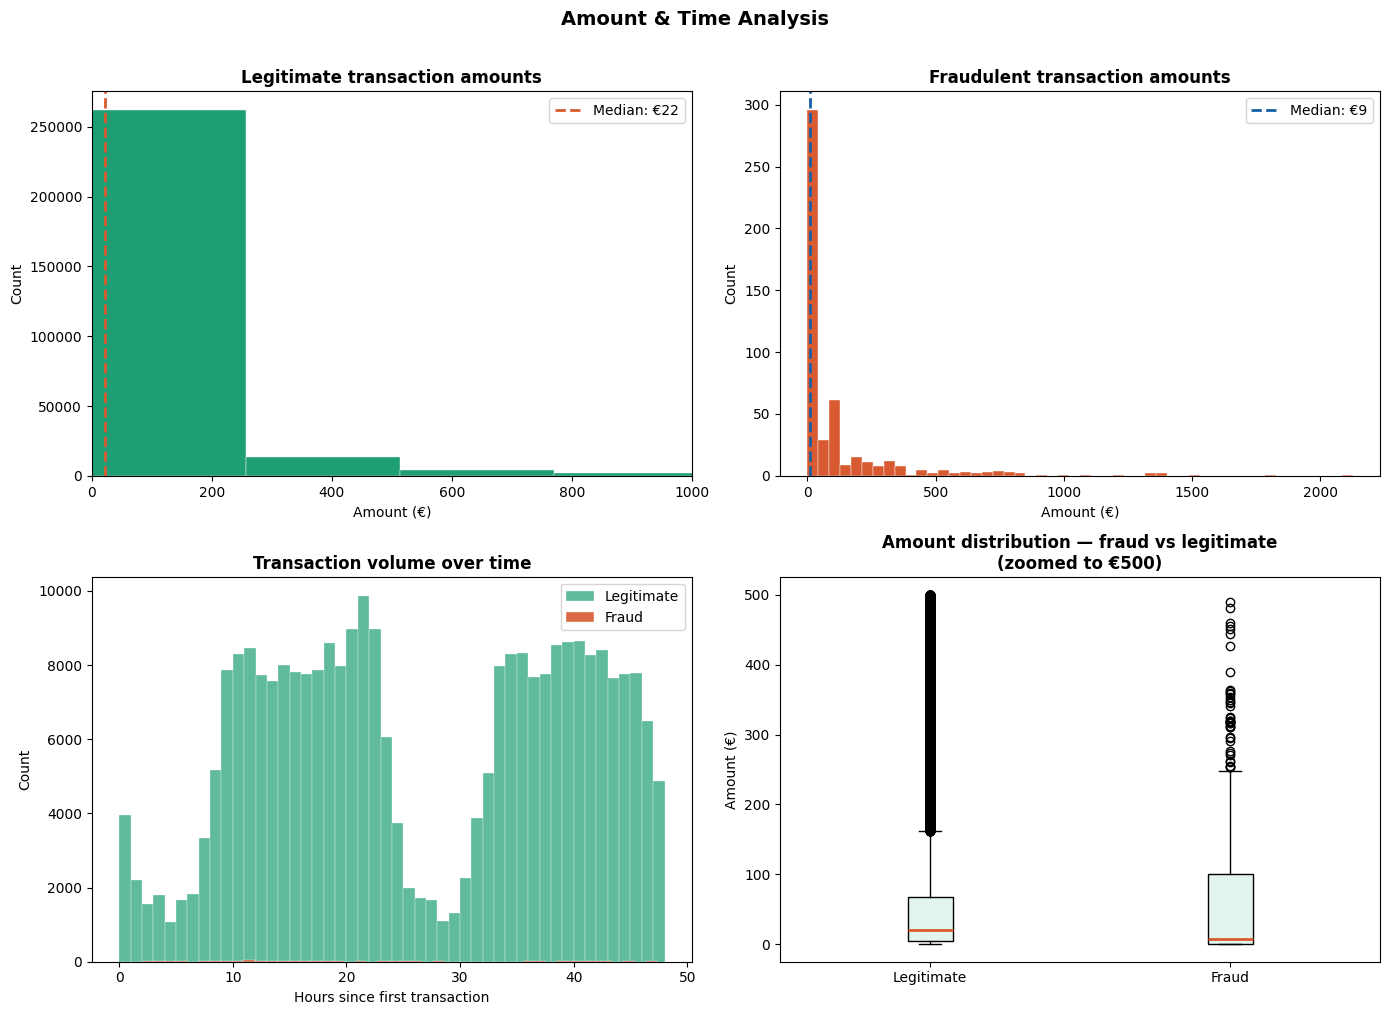

=== Amount Statistics ===
Legitimate — Median: €22.00 | Mean: €88.29 | Max: €25691.16
Fraud      — Median: €9.25 | Mean: €122.21 | Max: €2125.87

Zero-amount transactions: 1825 total | 27 are fraud


In [4]:
# ============================================================
# Amount & Time Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Amount distribution (legitimate)
legit_amount = df[df['Class']==0]['Amount']
axes[0,0].hist(legit_amount, bins=100, color='#1D9E75', 
               edgecolor='white', linewidth=0.3)
axes[0,0].set_title('Legitimate transaction amounts', fontweight='bold')
axes[0,0].set_xlabel('Amount (€)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xlim(0, 1000)  # zoom in — ignore extreme outliers
axes[0,0].axvline(legit_amount.median(), color='#D85A30', 
                  linestyle='--', linewidth=2,
                  label=f'Median: €{legit_amount.median():.0f}')
axes[0,0].legend()

# Chart 2 — Amount distribution (fraud)
fraud_amount = df[df['Class']==1]['Amount']
axes[0,1].hist(fraud_amount, bins=50, color='#D85A30', 
               edgecolor='white', linewidth=0.3)
axes[0,1].set_title('Fraudulent transaction amounts', fontweight='bold')
axes[0,1].set_xlabel('Amount (€)')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(fraud_amount.median(), color='#185FA5', 
                  linestyle='--', linewidth=2,
                  label=f'Median: €{fraud_amount.median():.0f}')
axes[0,1].legend()

# Chart 3 — Transaction volume over time
axes[1,0].hist(df[df['Class']==0]['Time']/3600, bins=48, 
               color='#1D9E75', edgecolor='white', 
               linewidth=0.3, alpha=0.7, label='Legitimate')
axes[1,0].hist(df[df['Class']==1]['Time']/3600, bins=48, 
               color='#D85A30', edgecolor='white', 
               linewidth=0.3, alpha=0.9, label='Fraud')
axes[1,0].set_title('Transaction volume over time', fontweight='bold')
axes[1,0].set_xlabel('Hours since first transaction')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Chart 4 — Amount comparison box plot
fraud_label    = ['Legitimate'] * len(legit_amount) 
fraud_label   += ['Fraud'] * len(fraud_amount)
amount_all     = pd.concat([legit_amount, fraud_amount])
plot_df        = pd.DataFrame({'Amount': amount_all, 
                               'Class': fraud_label})
plot_df_zoom   = plot_df[plot_df['Amount'] < 500]

axes[1,1].boxplot([
    plot_df_zoom[plot_df_zoom['Class']=='Legitimate']['Amount'],
    plot_df_zoom[plot_df_zoom['Class']=='Fraud']['Amount']
], labels=['Legitimate', 'Fraud'],
   patch_artist=True,
   boxprops=dict(facecolor='#E1F5EE'),
   medianprops=dict(color='#D85A30', linewidth=2))
axes[1,1].set_title('Amount distribution — fraud vs legitimate\n(zoomed to €500)', 
                     fontweight='bold')
axes[1,1].set_ylabel('Amount (€)')

plt.suptitle('Amount & Time Analysis', fontsize=14, 
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/02_amount_time_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
print("=== Amount Statistics ===")
print(f"Legitimate — Median: €{legit_amount.median():.2f} | "
      f"Mean: €{legit_amount.mean():.2f} | "
      f"Max: €{legit_amount.max():.2f}")
print(f"Fraud      — Median: €{fraud_amount.median():.2f} | "
      f"Mean: €{fraud_amount.mean():.2f} | "
      f"Max: €{fraud_amount.max():.2f}")
print(f"\nZero-amount transactions: "
      f"{(df['Amount']==0).sum()} total | "
      f"{(df[df['Class']==1]['Amount']==0).sum()} are fraud")

### Finding 1 — Amount & Time Patterns

**Amount:**
- Legitimate median: €22 | Fraud median: €9
- Contrary to intuition, fraud transactions are SMALLER on average
- Fraudsters use small probe transactions to test stolen cards
- Fraud has higher variance — some small, some large

**Time:**
- Legitimate transactions follow day/night patterns (drop at ~hours 24-32)
- Fraud occurs consistently across all hours — does not follow human sleep patterns
- Suggests automated fraud scripts or cross-timezone operations

**Implication for modelling:**
Amount and Time alone are insufficient to detect fraud. The PCA components V1-V28 capture behavioural signals (velocity, location, merchant patterns) that drive detection.

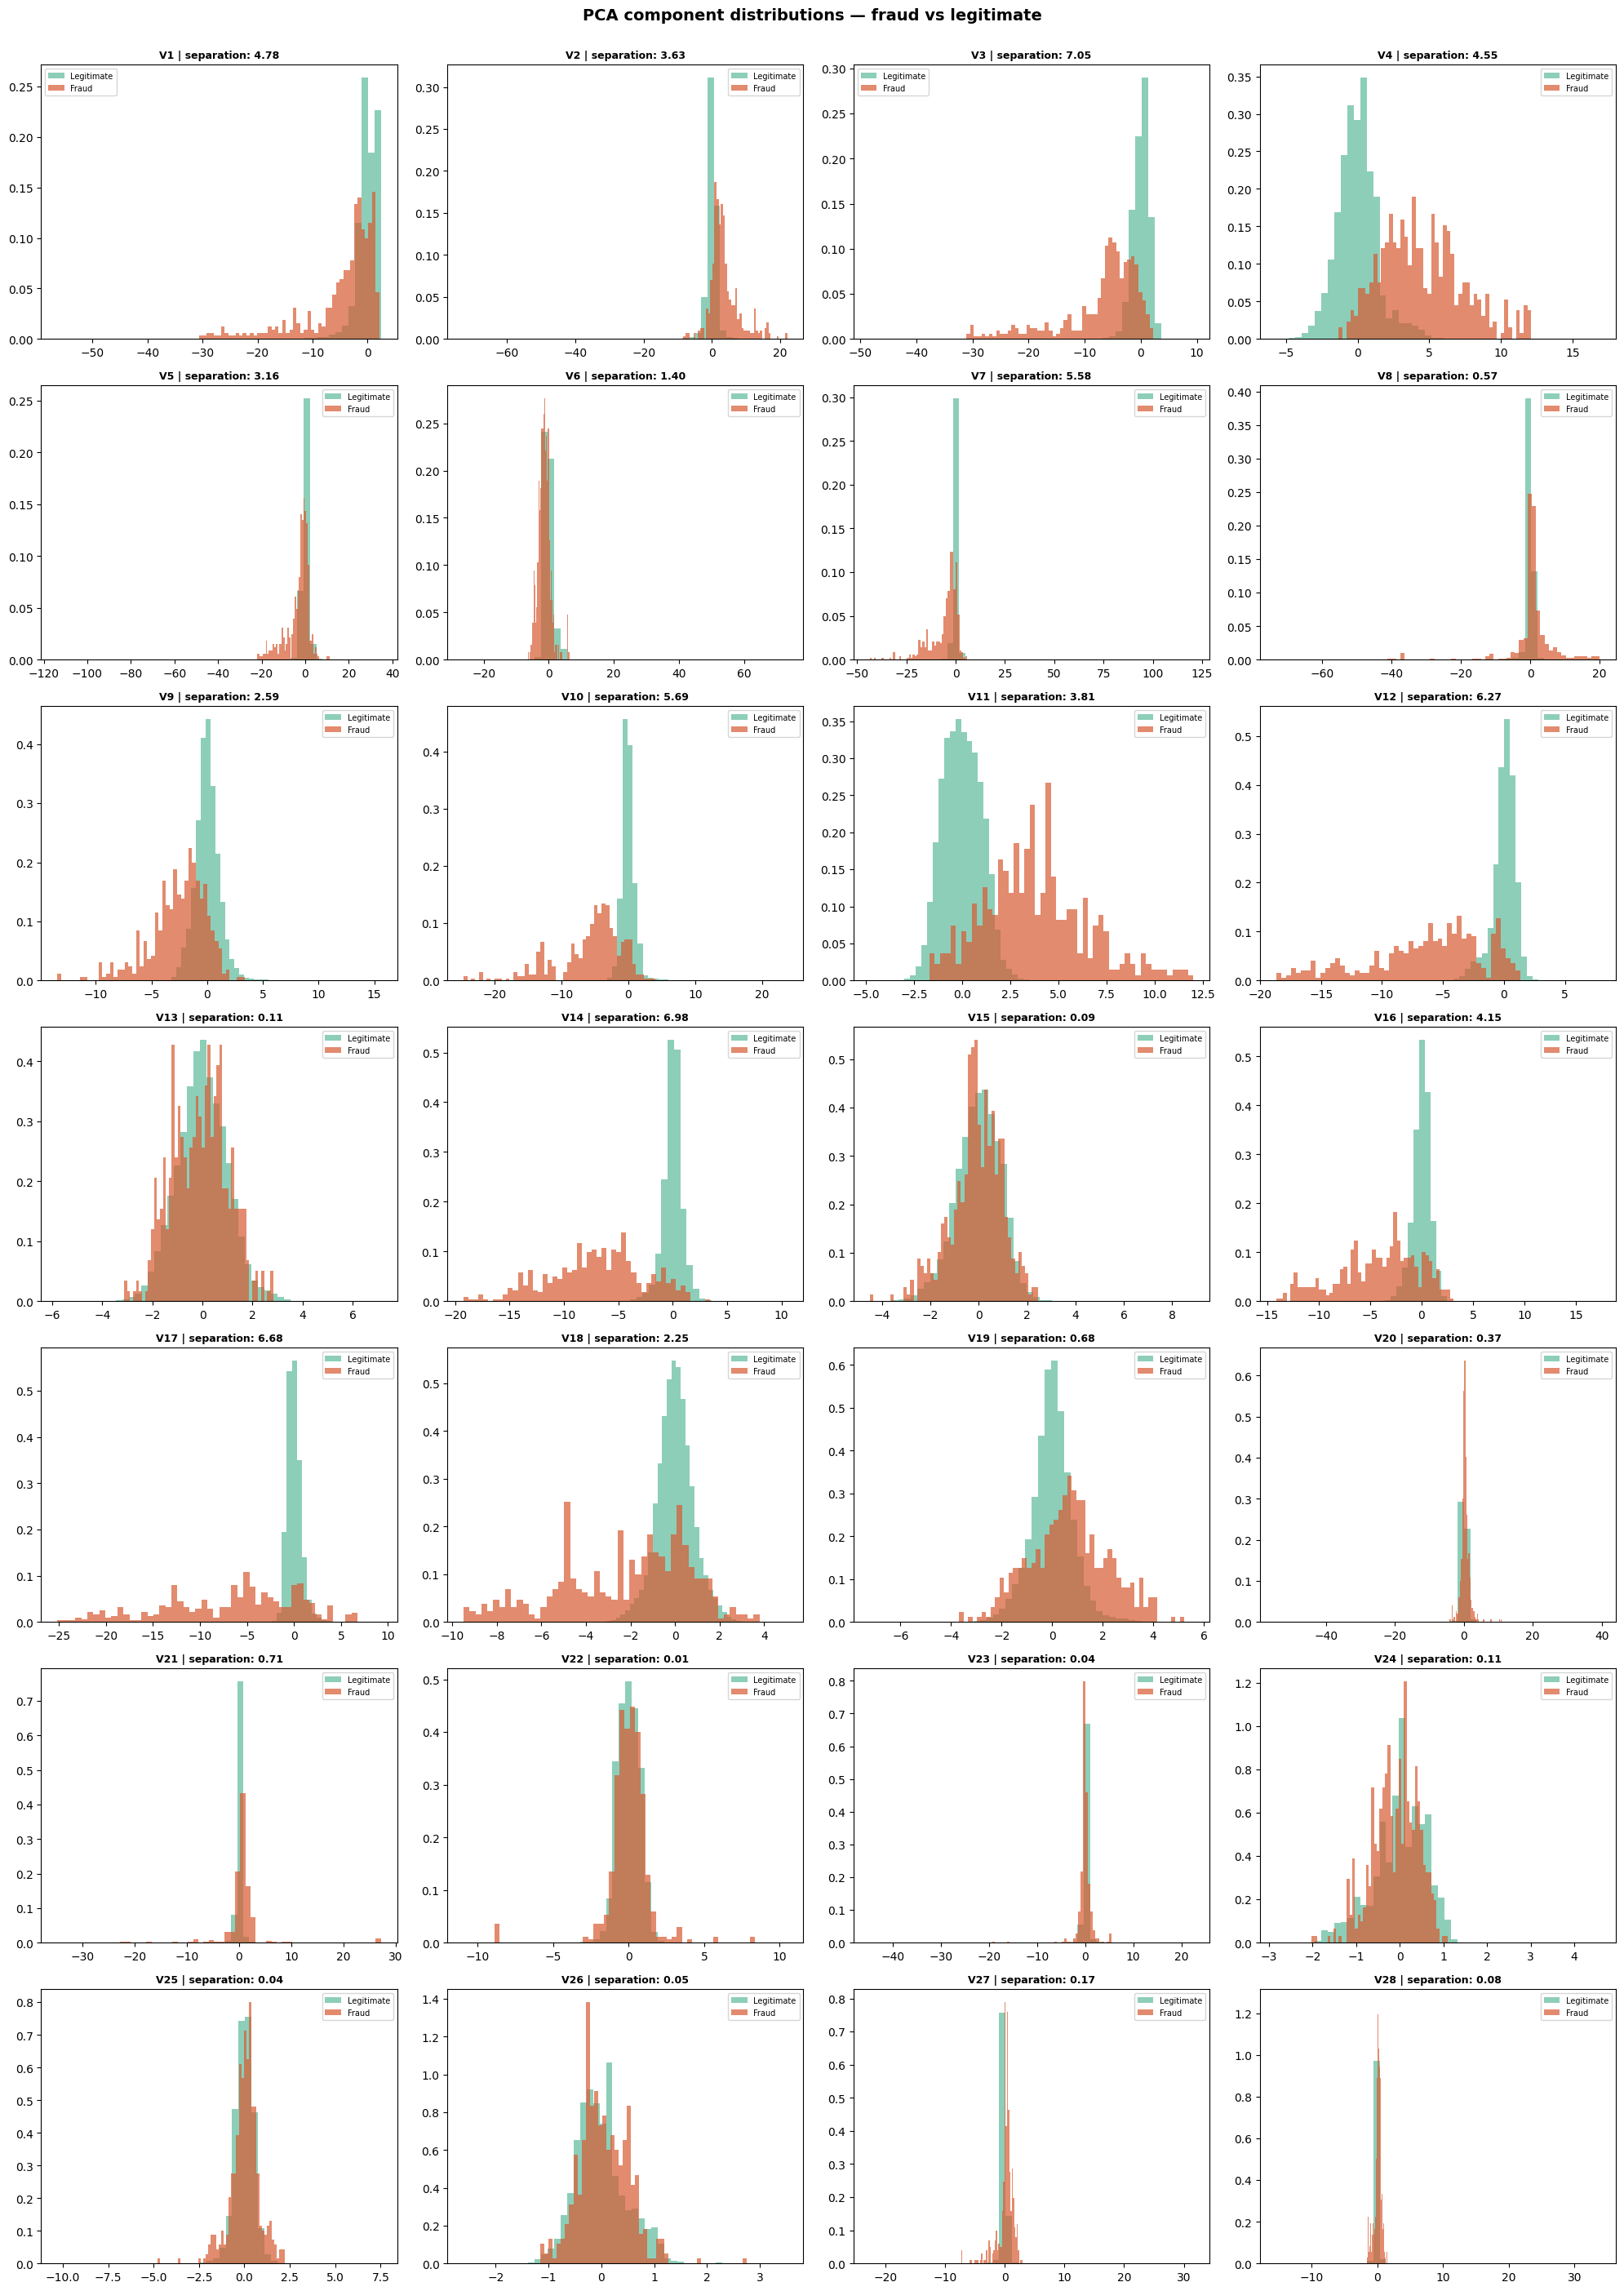

=== Top 10 most separating PCA components ===
     Mean Separation
V3            7.0455
V14           6.9838
V17           6.6774
V12           6.2702
V10           5.6867
V7            5.5784
V1            4.7802
V4            4.5499
V16           4.1471
V11           3.8067

These components will likely be most important in our model


In [5]:
# ============================================================
# PCA Component Analysis
# ============================================================

# For each V component, compare fraud vs legitimate distribution
v_cols = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    legit = df[df['Class']==0][col]
    fraud = df[df['Class']==1][col]
    
    axes[i].hist(legit, bins=50, alpha=0.5, color='#1D9E75',
                 density=True, label='Legitimate', edgecolor='none')
    axes[i].hist(fraud, bins=50, alpha=0.7, color='#D85A30',
                 density=True, label='Fraud', edgecolor='none')
    
    # Calculate separation (difference in means)
    separation = abs(legit.mean() - fraud.mean())
    axes[i].set_title(f'{col} | separation: {separation:.2f}', 
                      fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('PCA component distributions — fraud vs legitimate', 
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('../reports/03_pca_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 most separating components
separations = {}
for col in v_cols:
    sep = abs(df[df['Class']==0][col].mean() - 
              df[df['Class']==1][col].mean())
    separations[col] = round(sep, 4)

sep_df = pd.DataFrame.from_dict(separations, orient='index', 
                                 columns=['Mean Separation'])
sep_df = sep_df.sort_values('Mean Separation', ascending=False)

print("=== Top 10 most separating PCA components ===")
print(sep_df.head(10).to_string())
print("\nThese components will likely be most important in our model")

### Finding 2 — PCA Component Separation Analysis

Top 5 most separating components (strongest fraud signal):
1. V3  — separation 7.05
2. V14 — separation 6.98
3. V17 — separation 6.68
4. V12 — separation 6.27
5. V10 — separation 5.69

Weakest components (minimal fraud signal):
- V22, V23, V25, V26, V28 — separation < 0.10

Pattern observed: High-separation components show fraud distributions shifted toward negative values — consistent mathematical fingerprint across multiple PCA dimensions.

These rankings will be validated against XGBoost feature importance in the modelling phase.

In [6]:
# ============================================================
# Feature Engineering & Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

# ---- 1. Scale Amount ----
# Amount is in raw euros — very different scale from V1-V28 
# which are already standardised PCA components
# We log-transform first to handle the extreme right skew
# then standardise

df_clean['Amount_log'] = np.log1p(df_clean['Amount'])

scaler = StandardScaler()
df_clean['Amount_scaled'] = scaler.fit_transform(
    df_clean[['Amount_log']])

# ---- 2. Scale Time ----
# Convert seconds to hours and standardise
df_clean['Time_hours'] = df_clean['Time'] / 3600
df_clean['Time_scaled'] = scaler.fit_transform(
    df_clean[['Time_hours']])

# ---- 3. Add time-based features ----
# Hour of day — captures day/night pattern
df_clean['hour_of_day'] = df_clean['Time_hours'] % 24

# Is nighttime — hours 0-6 (midnight to 6am)
# Fraud doesn't sleep — this might be a useful signal
df_clean['is_night'] = (
    (df_clean['hour_of_day'] >= 0) & 
    (df_clean['hour_of_day'] <= 6)
).astype(int)

# ---- 4. Drop original Amount and Time ----
# We keep the engineered versions, not the raw ones
df_clean = df_clean.drop(columns=['Amount', 'Time', 
                                   'Amount_log', 'Time_hours'])

print("=== Feature Engineering Complete ===")
print(f"Original features: {df.shape[1]}")
print(f"Engineered features: {df_clean.shape[1]}")
print(f"\nNew features added:")
print("  Amount_scaled — log-transformed and standardised amount")
print("  Time_scaled   — standardised time")
print("  hour_of_day   — hour within 24-hour cycle")
print("  is_night      — binary flag for midnight to 6am")
print(f"\nFinal shape: {df_clean.shape}")

# Verify no missing values
print(f"Missing values: {df_clean.isnull().sum().sum()}")

# Quick check — is_night fraud rate
night_fraud = df_clean[df_clean['is_night']==1]['Class'].mean()*100
day_fraud   = df_clean[df_clean['is_night']==0]['Class'].mean()*100
print(f"\nFraud rate — daytime: {day_fraud:.3f}%")
print(f"Fraud rate — nighttime: {night_fraud:.3f}%")

=== Feature Engineering Complete ===
Original features: 31
Engineered features: 33

New features added:
  Amount_scaled — log-transformed and standardised amount
  Time_scaled   — standardised time
  hour_of_day   — hour within 24-hour cycle
  is_night      — binary flag for midnight to 6am

Final shape: (284807, 33)
Missing values: 0

Fraud rate — daytime: 0.141%
Fraud rate — nighttime: 0.518%


### Finding 3 — Feature Engineering Insights

**Amount:**
- Log transformation applied to handle extreme right skew
- Standardised to match scale of V1-V28 components

**Time features:**
- hour_of_day — captures circadian transaction patterns
- is_night (midnight to 6am) — binary fraud signal
  
**Night vs Day fraud rate:**
- Daytime fraud rate: 0.141%
- Nighttime fraud rate: 0.518%
- Fraud is 3.7x more likely at night
- Confirms fraudsters operate outside normal human hours

**Final dataset:** 284,807 transactions, 33 features, 0 missing values